# Hoofdstuk 5: Dataframes

Het basisidee van het dataframe is een uitbreiding van de één-dimensionale datastructuur uit het vorige hoofdstuk, met name de lijst. 

In een lijst heeft elke waarde een volgnummer, een index genoemd en zet je dus waarden achter elkaar.

In een dataframe heeft elke waarde een rij-nummer én een kolom-naam. Dit geeft twee dimensies.

## Het DataFrame mapt op Excel en CSV

Als het concept van cellen met een rij-nummer en een kolom-naam je een belletje doet rinkelen, dan heb je gelijk. Dit trekt heel fel op het concept van een Excel-document. In de praktijk zijn veel wetenschappers niet zo'n fan van Excel omdat dit een gesloten formaat is dat eigendom is van één firma en omdat het een vrij zwaar formaat is met ook informatie over de layout en zo. Voor pure gegevens is dat overkill.

Het formaat van de *Comma Separated Values* (of CSV) is in die zin beter. Het is in essentie een gewoon, plat tekstbestand met per rij een reeks waarden die met een komma van elkaar gescheiden worden. Omdat we in Vlaanderen de komma al gebruiken als decimale punt, gebruiken we de ; als scheidingsteken.

Een CSV kan er bijvoorbeeld als volgt uit zien:

rijksregister;postcode;IQ
04051712544;3500;106
07081915478;3600;123
99112454171;3960;88
70080314571;3130;117

Voor deze cursus leveren we heel wat csv-bestanden aan. We hebben die samen in een zip gestoken. Haal die zip af van Toledo, pak uit op je PC en upload in een aparte map *csv* in je Jupyterhub. 

# 5.2 DataFrame maken = CSV importeren

In de cursus staan verschillende manieren beschreven om een dataframe te maken. Wij gebruiken (bijna) altijd de techniek waarbij je een CSV-bestand inleest. 

Wanneer je hiervoor de bibliotheek pandas importeert, wordt dit heel gemakkelijk, bijvoorbeeld. 

In [ ]:
import pandas as pd
from qgridnext import show_grid

df1 = pd.read_csv("csv/autoverbruik.csv",sep=";",encoding="latin-1")
show_grid(df1)

We roepen de functie *read_csv* met drie parameters op
- de bestandsnaam van het csv-bestand
- welk scheidingsteken we gebruiken (de separator). Voor ons is dit steeds ;
- en een encoding: de tekenset die in de data gebruikt wordt. Voor ons is dit latin-1, maar Oekraïener, Welshmen, Indiers, ... gebruiken mogelijk een andere codering.

In [ ]:
# probeer zelfs een ander bestand te importeren
# druk achter csv/ op tab en zie alle bestanden verschijnen
df2 = pd.read_csv("csv/",sep=";",encoding="latin-1")
show_grid(df2)

## 5.3 Gegevens opvragen en aanpassen in een dataframe

Dit is gedeeltelijk analoog aan het werken met lijsten. Daar gebruikten we de vierkante haken [] achter de naam van de variabele, met tussen de haken de index.

Voor het dataframe hebben we ook vierkante haken met twéé indexen, maar moeten we bijkomend .loc schrijven.

In [ ]:
print(df1.loc[7,"auto_uit_2013"]) # rij 7, kolom auto_uit_2013

In [ ]:
print(df1.loc[6,"auto_uit_2013"])
df1.loc[6,"auto_uit_2013"] = "golfke"
print(df1.loc[6,"auto_uit_2013"])

# De lengte van een DataFrame

Dit is dezelfde functie als bij de lijst, nl. *len*.
Als resultaat krijg je het aantal rijen terug.

# Geaggregeerde gegevens via sum, prod, cumsum, cumprod, min, max, mean, median

Bij de lijst heb je handige functies waarmee je direct de som, product, gemiddelde, ... van een lijst kan berekenen.
Dat heb je ook bij het dataframe, maar daar zijn het wel *methodes* wat inhoudt dat je eerst het object moet vastgrijpen en dan de methode kan uitvoeren.

Je kan de methodes .sum(), .prod(), .min(), .max(), .mean(), .median(), .cumsum(), .cumprod() op het hele dataframe loslaten: dan krijg je som, product, ... per kolom. Als je 4 kolommen had, krijg je dan een rij met 4 uitkomsten.

Wanneer je dit op één kolom wil toepassen, dan kan je best eerst de kolom selecteren (bv. df["A"]) en dan de methode oproepen, bv. df["A"].sum().

In [ ]:
# voorbeeld
df_autos = pd.read_csv("csv/autoverbruik.csv",sep=";",encoding="latin-1")
gemiddeld_diesel = df_autos["diesel_gemeten"].mean()
min_verbruik_diesel = df_autos["diesel_gemeten"].min()
max_verbruik_diesel = df_autos["diesel_gemeten"].max()
print(f"Het gemiddelde gemeten dieselverbruik is {gemiddeld_diesel} met uitschieters tot {min_verbruik_diesel} en {max_verbruik_diesel}")

In [ ]:
df_strava = pd.read_csv("csv/sporttijden.csv", sep=";")
show_grid(df_strava)

In [ ]:
df_totalen = df_strava.sum()
df_totalen

In [ ]:
df_strava.mean()["afstand"]

In [ ]:
df_strava["afstand"].mean()

### 5.3.4	BESCHRIJVENDE INFO OPHALEN UIT EEN DATAFRAME
We verwezen hierboven al naar het feit dat we later eenvoudige data-analyse doen, maar je kan alvast de belangrijkste statistische gegevens opvragen met de methode describe(), bijvoorbeeld

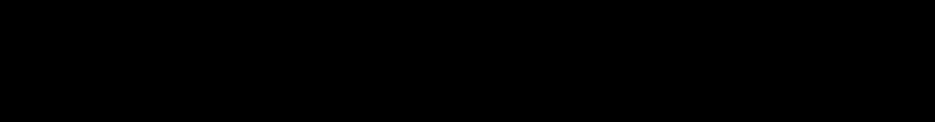

In [ ]:
df_strava.describe()

# 5.5 Transformaties op hoog niveau
## 5.5.1 Rijen filteren

Rijen selecteren die voldoen aan een bepaalde voorwaarde is een heel courante actie bij data-analyse. Zo kan je bijvoorbeeld de goedkoopste, snelste, maximale, efficiëntste, … waarde en/of opstelling vinden.

### Filteren op basis van een functie

Wanneer een functie die een rij als input krijgt en een boolean teruggeeft, kan je de functie eenvoudig tussen de vierkante haken zetten. Dan wordt er volgens die functie gefilterd op rijen.

Hieronder vind je twee voorbeelden: een uit de cursus en een uit de powerpoint.

In [ ]:
# voorbeeld 1: uit de cursus
df_elektriciteit = pd.DataFrame()
df_elektriciteit["U"] = [220, 233, 5.2]
df_elektriciteit["I"] = [12, 3.08, 2.11]
df_elektriciteit["P"] = df_elektriciteit["I"] * df_elektriciteit["U"]

def veel_vermogen(rij):
    return rij["P"] > 2200

df_veel_vermogen = df_elektriciteit[veel_vermogen]
show_grid(df_veel_vermogen)

In [ ]:
# voorbeeld 2: uit de powerpoint
def bijna_vierkant(rij):
    ratio = rij["b"]/rij["h"]
    return (ratio > 0.9) & (ratio < 1.1)

rects = pd.DataFrame()
rects["b"] = [4,3,5,2]
rects["h"] = [5,6,8,2]

bijna_vierkante_rects = rects[bijna_vierkant]
show_grid(bijna_vierkante_rects)

## Filteren met een expressie

Het kan nog iets korter: in plaats van een functie mag je ook een expressie met kolommen tussen de vierkante haken zetten.

In [ ]:
# voorbeeld
df_elektriciteit[  df_elektriciteit["I"] > 3]

Die expressie mag natuurlijk ook andere expressies gebruiken. I.p.v. de constante 3 van hierboven, zouden we ook het gemiddelde van een kolom kunnen nemen of andere interessante berekeningen gebruiken.

In [ ]:
df_elektriciteit[  df_elektriciteit["U"] > df_elektriciteit["U"].mean()]

Als je voorwaarden wil combineren, moet elke voorwaarde *tussen haakjes* staan en moet je die voorwaarden combineren met *& of |* (en vs of). Je mag dus niet and of or gebruiken, zoals het wél bij de if moet.

In [ ]:
df_elektriciteit[ (df_elektriciteit["U"] > 200) & (df_elektriciteit["I"] > 10)]

## De grootste of kleinste waarde zoeken kan ook.

De expressie van hierboven kan ook een expressie zijn die gebruik maakt van een berekening over alle rijen. Hieronder twee voorbeelden:

In [ ]:
df_maximaal_vermogen = df_elektriciteit[df_elektriciteit["P"] == max(df_elektriciteit["P"])]
print(df_maximaal_vermogen)
print("-----------------")

df_redelijk_veel_spanning = df_elektriciteit[df_elektriciteit["U"] > df_elektriciteit["U"].mean()]
print(df_redelijk_veel_spanning)

In het tweede voorbeeld zullen er in het algemeen ongeveer de helft van de rijen geselecteerd worden, maar in het tweede voorbeeld zal je waarschijnlijk verwachten dat er maar één rij met het maximum is. Daar kan je echter niet zeker van zijn. Python gaat dat sowieso niet zijn en zal dus altijd een dataframe teruggeven bij het gebruik van die filter.

Wanneer je dan een specifieke waarde uit het dataframe wil halen, moet je eerst de gewenste rij selecteren en daaruit de gewenste kolom. Hiervoor kan je in principe de *.loc* gebruiken, maar het probleem is dat de nummer van de rijen de oorspronkelijke nummering houdt. Omdat je niet op voorhand weet welk rijnummer over zal blijven, is het lastig om de methode *.loc* te gebruiken. Beter is om in dit geval de *.iloc* te gebruiken. Die gebruikt als nummering de nieuwe rangnummers. *.iloc[0]* zal dan altijd de eerste rij uit het resultaat bevatten.

Concreet: wanneer je wil weten bij welk voltage het maximale vermogen optrad, moet je onderstaande manier gebruiken:

In [ ]:
df_maximaal_vermogen = df_elektriciteit[df_elektriciteit["P"] == max(df_elektriciteit["P"])]
spanning_bij_max_p = df_maximaal_vermogen.iloc[0]["U"]   # zorg ervoor dat je één rij selecteert
print(spanning_bij_max_p, "V")

#5.5.3 Nieuwe kolommen maken via vectorgebaseerde kolom-bewerkingen

Python gaat steeds voor syntax die zo inituitief mogelijk is.
Wanneer je bijvoorbeeld een dataframe hebt met een kolom "aantal" en een tweede kolom "prijs" voor de prijs per stuk, dan is de kans groot dat je de totaalprijs wil berekenen per rij door aantal en prijs per rij te vermenigvuldigen. Intuitief zou je zeggen dat je beide kolommen vermenigvuldigt met elkaar. In de syntax schrijf je dat exact hetzelfde.

In [ ]:
df_elektriciteit["P"] = df_elektriciteit["U"] * df_elektriciteit["I"]
df_elektriciteit

In [ ]:
# voorbeeld
df_sales = pd.DataFrame()
df_sales["aantal"]=[10, 5, 18, 100]
df_sales["prijs"]=[0.25, 9.99, 3.00, 4.95]
df_sales["totaalPrijs"] = df_sales["aantal"] * df_sales["prijs"]
show_grid(df_sales)

## 5.5.4 Functies toepassen op een volledige rij: apply

De vectoriële bewerkingen genieten de absolute voorkeur wanneer het om relatief eenvoudige bewerkingen gaat, maar wanneer de berekening per rij complex wordt, kan je die beter in een aparte functie zetten die op één rij werkt en dan die functie loslaten op elke rij. Dat loslaten doe je met de **apply**.

Wanneer we met de apply een functie loslaten op elke rij, krijg je een nieuwe kolom. Die kolom kan je dan perfect toevoegen aan het dataframe.

Schematisch verloopt dit als volgt:

`nieuwe_kolom = df.apply(functie, axis=1)`

of

`df[naam_kolom] = df.apply(functie, axis=1)`

De parameter *axis=1* is nodig omdat apply anders op de kolommen zou werken, en dat is (voor ons meestal) niet de bedoeling.

### Functie moet één parameter hebben

Belangrijke, maar eigenlijk logische opmerking is dat de functie maar één parameter mag hebben. Dat is logisch omdat je de hele rij binnenkrijgt als parameter.

De volgende functie is dus niet bruikbaar.

In [ ]:
def oppervlakte(basis, hoogte):
    return basis * hoogte

Wanneer de kolommen van het dataframe b en h zouden heten, is volgende functie wél mogelijk.

In [ ]:
def opp(rij):
    return oppervlakte(rij["b"], rij["h"])

In de volgende codeblok passen we deze functie toe op elke rij.

In [ ]:
rects = pd.DataFrame()
rects["b"] = [4,3,5,2]
rects["h"] = [5,6,8,2]
print(rects)

rects["opp"] = rects.apply(opp, axis=1)
print(rects)

Bovenstaande is niet zo'n geweldig voorbeeld omdat je daarvoor beter de gewone vectoriële bewerking had gebruikt.

Onderstaand voorbeeld is wél veel beter omdat de functie is_geslaagd toch al enkele regels in beslag neemt.

In [ ]:
def is_geslaagd(rij):
   if rij["aantal_onvoldoendes"] == 0:
       return True
   if rij["percentage"] >= 54 and rij["aantal_8_of_9"] == 1:
       return True
   if rij["percentage"] >= 58 and rij["aantal_8_of_9"] == 2:
       return True
   return False

# Met het juiste dataframe zou onderstaande code werken.
# df_studenten["geslaagd"] = df_studenten.apply(is_geslaagd, axis=1)

# 5.5.5 Het dataframe sorteren volgens eens of meer kolommen: sort_values

Een dataframe komt (in deze cursus) vooral uit een csv-bestand waarbij de data typisch uit wetenschappelijke experimenten komt. De volgorde van die experimenten is dan chronologisch, maar in bepaalde gevallen willen we een andere volgorde, bijvoorbeeld het elektriciteitsdataframe volgens stijgend vermogen, de studenten volgens dalend percentage, …

Dit kan heel gemakkelijk via de methode sort_values. Je kan die op vier manieren oproepen:

-	Met één parameter van het type string: de kolom waarop gesorteerd moet worden, bv.

     `df_gesorteerd = df_studenten.sort_values("aantal_onvoldoendes")`

-	Omdat dit standaard alfabetisch of stijgend gesorteerd wordt, kan je ook een extra parameter ascending toevoegen met als waarde True of False.
  Je kan bijvoorbeeld de studenten sorteren van zeer sterk tot minder sterk:

  `df2 = df_studenten.sort_values("percentage", ascending= False).`

-	Wanneer de eerste parameter een lijst van strings is, wordt er eerst gesorteerd op de eerste kolom van de lijst: wanneer verschillende rijen dezelfde waarde voor die kolom hebben, wordt naar de 2e kolom in de lijst gekeken, enzoverder.

  `df_sorted = dfA.sort_values(["A","B")]).`

-	In de laatste variant kan je per kolom kiezen of er stijgend of dalend gesorteerd moet worden. De parameter ascending moet dan een lijst van booleans krijgen.

   `df_sorted = dfA.sort_values(["A","B")], ascending= [False, True]).`



In [ ]:
df_elektriciteit.sort_values("P")

In [ ]:
df_strava.sort_values(["afstand","minuten","seconden"],ascending=[False, True, True])

# Oefeningen

1. In het csv-bestand zonnepaneel.csv staan opgemeten gegevens van stroom en spanning van een zonnepaneel. Haal dat bestand op en voeg aan het dataframe een kolom toe die het vermogen berekent via de formule P = U∙I. Bereken dan het maximaal vermogen.

In [ ]:
# oplossing voor oefening 1
import pandas as pd

def maximaal_vermogen(zonnepanelen = "csv/zonnepaneel.csv"):
    df = pd.read_csv(zonnepanelen,sep=";",encoding="latin-1")
    return df

print(maximaal_vermogen())

2. In het csv-bestand autoverbruik.csv staan gegevens van het verbruik per auto in l/100 km.
Zet dit voor elke auto om in het aantal kilometer dat je per liter kan rijden.

In [ ]:
# oplossing voor oefening 2

# maak voor deze functie 2 kolommen
#    - dieselKmPerL op basis van het gemeten dieselverbruik
#    - benzineKmPerL op basis van het gemeten benzineverbruik
def autoverbruik(autos = "csv/autoverbruik.csv"):
    df = pd.read_csv(autos, sep=";", encoding="latin-1")
    return df

show_grid(autoverbruik())

3. In het csv-bestand elektrisch verbruik staat van een aantal elektrische toestellen hoeveel Watt dat zij verbruiken, hoeveel uur per jaar dat die opstaan en hoeveel van dergelijke toestellen er in een bepaalde woning staan. Bereken dan het totaal elektrisch verbruik voor die woning.

In [ ]:
# oplossing voor oefening 3
def elektrisch_verbruik_in_kWh(huis ="csv/elektriciteitsverbruik.csv"):
    df = pd.read_csv(huis, sep=";", encoding="latin-1")
    return totaal

print(elektrisch_verbruik_in_kWh())

4. Voeg aan het csv-bestand rechthoeken.csv kolommen met omtrek en oppervlakte.

In [ ]:
# oplossing voor oefening 4
def rh_met_info(rects ="csv/rechthoeken.csv"):
    df = pd.read_csv(rects, sep=";", encoding="latin-1")
    return df

rh_met_info()

5. Voeg aan het csv-bestand landgebruik_2015.csv een kolom toe met de gemiddelde oppervlakte per perceel (= totale_opp_ha  / aantal_percelen).

In [ ]:
# oplossing voor oefening 5
def voeg_gemiddelde_oppervlakte_toe(kadasterInfo ="csv/landgebruik_2015.csv"):
    df = pd.read_csv(kadasterInfo, sep=";", encoding="latin-1")
    df.to_csv("csv/landgebruik_2015_uitgebreid.csv",sep=";",encoding='latin-1')

voeg_gemiddelde_oppervlakte_toe()
show_grid(pd.read_csv("csv/landgebruik_2015_uitgebreid.csv", sep=";", encoding="latin-1"))

6. In het csv-bestand diepvriezers.csv vind je de kostprijs van een aantal diepvriezers en hun jaarlijks verbruik. In deze csv staat ook de huidige diepvriezer die ‘gratis’ is, maar wel een hoog verbruik kent. Bereken de gecumuleerde kostprijs van de diepvries (aankoop + jaarlijks verbruik) na 10 jaar en geef de naam van de goedkoopste diepvriezer.
Maak de simulatie zowel voor een energieprijs van 28 eurocent/kWh en 40 eurocent/kWh

In [ ]:
# oplossing voor oefening 6
def kostprijs_diepvries(aantalJaar, prijskWh = 0.28, bestand ="csv/diepvries.csv"):
    df = pd.read_csv(bestand, sep=";", encoding="latin-1")
    return df

def goedkoopste_diepvries(aantalJaar, prijskWh = 0.28, bestand ="csv/diepvries.csv"):
    return

def naam_goedkoopste_diepvries(aantalJaar, prijskWh = 0.28, bestand ="csv/diepvries.csv"):
    return

print(naam_goedkoopste_diepvries(10, 0.40))